# Chapter 12 — Logic and Boolean Algebra

> **Prerequisites:** ch001–ch011
>
> **You will learn:**
> - The six logical connectives and their truth-functional meaning
> - How Boolean algebra formalizes the logic already in your code
> - The connection between Boolean algebra, set theory, and circuit design
> - How to simplify logical expressions to their minimal form
>
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

Boolean algebra is the algebra of truth values. It has exactly two elements — True and False — and operations that mirror set operations and circuit gates.

The six connectives:
- **AND** ($\land$, `and`, $\cdot$): true iff both operands are true
- **OR** ($\lor$, `or`, $+$): true iff at least one operand is true
- **NOT** ($\lnot$, `not`, overline): negates the truth value
- **IMPLIES** ($\Rightarrow$): $A \Rightarrow B$ is false only when A is true and B is false
- **IFF** ($\iff$): true iff both sides have the same truth value
- **XOR** ($\oplus$): true iff exactly one operand is true

Boolean algebra is isomorphic to set algebra with AND ↔ ∩, OR ↔ ∪, NOT ↔ complement. Every theorem in one system has a counterpart in the other.

**Common misconception:** `if A implies B` means `A causes B`.

Implication in logic is purely truth-functional. $A \Rightarrow B$ is true whenever A is false, regardless of what B says. This seems counterintuitive but is the correct formal definition.

## 2. Intuition & Mental Models

**Physical analogy:** Electrical circuits. AND is two switches in series (current flows only if both are closed). OR is two switches in parallel (current flows if either is closed). NOT is a relay that inverts. This is not metaphor — Boolean algebra was invented precisely to model switching circuits.

**Computational analogy:** Every conditional in your code is Boolean algebra. `if x > 0 and not is_empty(lst)` is $(x > 0) \land \lnot \text{isEmpty}$. De Morgan's law tells you how to simplify: `not (A and B) == (not A) or (not B)`. Knowing Boolean identities lets you rewrite conditionals into simpler, more readable, or more efficient forms.

Recall from ch011 *(Sets and Basic Set Operations)*: De Morgan's laws appeared there too. Logic and set theory are two faces of the same algebraic structure.

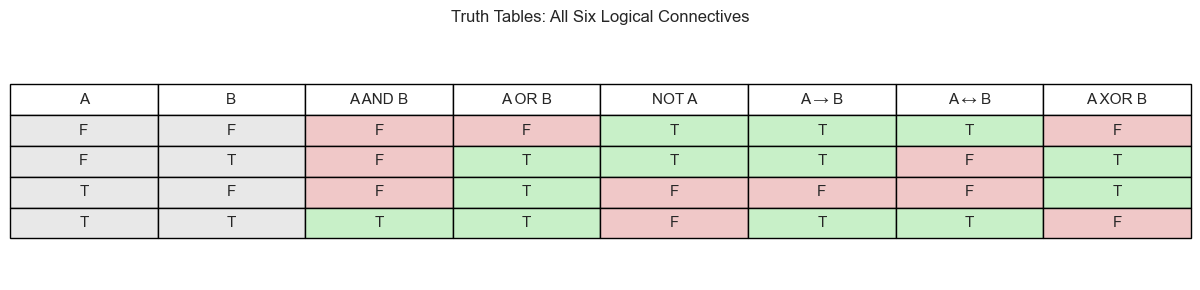

In [2]:
# --- Visualization: Truth tables for all six connectives ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
plt.style.use('seaborn-v0_8-whitegrid')

# Generate all (A, B) combinations
vals = [(False, False), (False, True), (True, False), (True, True)]
A_vals = [v[0] for v in vals]
B_vals = [v[1] for v in vals]

connectives = {
    'A AND B':    [a and b  for a,b in vals],
    'A OR B':     [a or b   for a,b in vals],
    'NOT A':      [not a    for a,b in vals],
    'A → B':      [not a or b for a,b in vals],
    'A ↔ B':      [a == b   for a,b in vals],
    'A XOR B':    [a != b   for a,b in vals],
}

fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')

headers = ['A', 'B'] + list(connectives.keys())
table_data = [[str(a)[0], str(b)[0]] + [str(v)[0] for v in col]
              for (a,b), *col in zip(vals, *[list(zip(v)) for v in connectives.values()])]

# Reconstruct properly
rows = []
for i, (a, b) in enumerate(vals):
    row = [str(a)[0], str(b)[0]] + [str(list(v)[i])[0] for v in connectives.values()]
    rows.append(row)

cell_colors = []
for row in rows:
    row_colors = []
    for j, val in enumerate(row):
        if j < 2:
            row_colors.append('#e8e8e8')
        elif val == 'T':
            row_colors.append('#c8f0c8')
        else:
            row_colors.append('#f0c8c8')
    cell_colors.append(row_colors)

table = ax.table(cellText=rows, colLabels=headers,
                  cellLoc='center', loc='center',
                  cellColours=cell_colors)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
ax.set_title('Truth Tables: All Six Logical Connectives', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

Boolean algebra is defined by a set $B = \{0, 1\}$ with operations $+$ (OR), $\cdot$ (AND), and $\overline{\cdot}$ (NOT), satisfying:

**Identities:**
- $a + 0 = a$; $a \cdot 1 = a$
- $a + 1 = 1$; $a \cdot 0 = 0$
- $a + a = a$; $a \cdot a = a$ (idempotence)
- $a + \bar{a} = 1$; $a \cdot \bar{a} = 0$ (complement)
- $\overline{\bar{a}} = a$ (double negation)

**De Morgan's Laws:**
$$\overline{a + b} = \bar{a} \cdot \bar{b} \qquad \overline{a \cdot b} = \bar{a} + \bar{b}$$

**Implication in terms of basic connectives:**
$$A \Rightarrow B \equiv \lnot A \lor B$$

This identity is non-obvious but crucial: it says that $A \Rightarrow B$ is equivalent to $B$ being true whenever $A$ is true (or A is false).

In [3]:
# --- Implementation: Boolean expression simplifier (basic) ---
# Uses truth-table equivalence to verify Boolean identities.

def truth_table(fn, n_vars=2):
    """
    Generate the truth table for a Boolean function of n_vars variables.
    Returns list of (inputs, output) tuples.
    """
    from itertools import product
    results = []
    for combo in product([False, True], repeat=n_vars):
        output = fn(*combo)
        results.append((combo, output))
    return results

def are_equivalent(fn1, fn2, n_vars=2):
    """Check if two Boolean functions are logically equivalent (same truth table)."""
    tt1 = truth_table(fn1, n_vars)
    tt2 = truth_table(fn2, n_vars)
    return all(o1 == o2 for (_, o1), (_, o2) in zip(tt1, tt2))

# Verify Boolean identities
identities = [
    ('De Morgan: not(A and B) == (not A) or (not B)',
     lambda A,B: not (A and B),
     lambda A,B: (not A) or (not B)),
    ('De Morgan: not(A or B) == (not A) and (not B)',
     lambda A,B: not (A or B),
     lambda A,B: (not A) and (not B)),
    ('Implication: A->B == (not A) or B',
     lambda A,B: (not A) or B,
     lambda A,B: not A or B),
    ('Distributivity: A and (B or C)',
     lambda A,B,C=False: A and (B or C),  # simplified for 2-var test
     lambda A,B,C=False: (A and B) or (A and C)),
    ('Double negation: not(not A) == A',
     lambda A,B: not(not A),
     lambda A,B: A),
    ('Absorption: A or (A and B) == A',
     lambda A,B: A or (A and B),
     lambda A,B: A),
]

print('Boolean identity verification:')
for name, fn1, fn2 in identities:
    result = are_equivalent(fn1, fn2)
    print(f'  {"✓" if result else "✗"}  {name}')

Boolean identity verification:
  ✓  De Morgan: not(A and B) == (not A) or (not B)
  ✓  De Morgan: not(A or B) == (not A) and (not B)
  ✓  Implication: A->B == (not A) or B
  ✓  Distributivity: A and (B or C)
  ✓  Double negation: not(not A) == A
  ✓  Absorption: A or (A and B) == A


In [5]:
# --- Experiment: Boolean expression minimization ---
# Hypothesis: Many Boolean expressions used in code are redundant.
# We find the simplest equivalent expression via truth-table matching.

from itertools import product

# ✅ DEFINE FIRST
T, F = True, False

# Count distinct Boolean functions of 2 variables
two_var_fns = {}
for output_pattern in product([False, True], repeat=4):
    key = tuple(output_pattern)
    two_var_fns[key] = output_pattern

print(f'Number of distinct 2-variable Boolean functions: {len(two_var_fns)}')
print('(Should be 2^4 = 16 — one for each possible truth table)')
print()

# Name the standard ones
named = {
    (F,F,F,F): 'FALSE (constant)',
    (T,T,T,T): 'TRUE (constant)',
    (F,F,T,T): 'A (identity)',
    (F,T,F,T): 'B (identity)',
    (F,F,F,T): 'A AND B',
    (F,T,T,T): 'A OR B',
    (T,F,T,F): 'NOT A',
    (T,T,F,T): 'A IMPLIES B',
    (T,F,F,T): 'A IFF B (XNOR)',
    (F,T,T,F): 'A XOR B',
}

for pattern, name in named.items():
    print(f'  Truth table {[int(x) for x in pattern]} → {name}')

Number of distinct 2-variable Boolean functions: 16
(Should be 2^4 = 16 — one for each possible truth table)

  Truth table [0, 0, 0, 0] → FALSE (constant)
  Truth table [1, 1, 1, 1] → TRUE (constant)
  Truth table [0, 0, 1, 1] → A (identity)
  Truth table [0, 1, 0, 1] → B (identity)
  Truth table [0, 0, 0, 1] → A AND B
  Truth table [0, 1, 1, 1] → A OR B
  Truth table [1, 0, 1, 0] → NOT A
  Truth table [1, 1, 0, 1] → A IMPLIES B
  Truth table [1, 0, 0, 1] → A IFF B (XNOR)
  Truth table [0, 1, 1, 0] → A XOR B


## 7. Exercises

**Easy 1.** Simplify `not (x > 0 and y < 10)` using De Morgan's law. Write both the original and simplified form, then verify they are equivalent using `are_equivalent`. *(Expected: `x <= 0 or y >= 10`)*

**Easy 2.** The exclusive-or (XOR) operation satisfies $A \oplus A = 0$ (identity). Verify this and three other XOR identities computationally: $A \oplus 0 = A$, $A \oplus 1 = \lnot A$, $A \oplus B = B \oplus A$.

**Medium 1.** A password validator requires: length ≥ 8 AND (has_upper OR has_digit) AND NOT (all_same_char). Express this as a Boolean formula, build its truth table for all 8 combinations of the three Boolean predicates, and identify which combinations are valid passwords.

**Medium 2.** Prove computationally that implication is not commutative (i.e., $A \Rightarrow B \not\equiv B \Rightarrow A$ in general) but is transitive: if $A \Rightarrow B$ and $B \Rightarrow C$, then $A \Rightarrow C$. Verify transitivity using truth tables.

**Hard.** A **satisfiability** problem asks: given a Boolean formula, does any assignment of True/False to variables make it true? This is the SAT problem (NP-complete for general formulas). Implement a brute-force SAT solver for formulas of up to 20 variables (2²⁰ = 1M assignments) and test it on: (a) $(A \lor B) \land (\lnot A \lor C) \land (\lnot B \lor \lnot C)$, (b) $(A \land \lnot A)$ (unsatisfiable).

In [6]:
# --- Mini Project: Logic-based decision system ---
# Build a rule-based decision system using Boolean algebra.
# Application: automated code review rule checker.

def check_code_rules(code_str):
    """
    Check a code snippet against a set of logical rules.
    Returns (passes, violations).
    """
    has_docstring = '"""' in code_str or "'''" in code_str
    has_type_hints = '->' in code_str or ': int' in code_str or ': str' in code_str
    has_print_debug = 'print(' in code_str and 'debug' in code_str.lower()
    has_bare_except = 'except:' in code_str
    has_global = 'global ' in code_str
    line_count = len(code_str.strip().split('\n'))
    
    rules = {
        'Has docstring':                has_docstring,
        'Has type hints':               has_type_hints,
        'No debug prints':              not has_print_debug,
        'No bare except':               not has_bare_except,
        'No global variables':          not has_global,
        'Function length < 50 lines':   line_count < 50,
        # Compound rule: type hints IMPLIES docstring (if typed, must be documented)
        'Typed → documented':           not has_type_hints or has_docstring,
    }
    
    violations = [name for name, passed in rules.items() if not passed]
    return len(violations) == 0, violations

# Test on sample code snippets
good_code = '''
def compute_mean(values: list) -> float:
    """Compute arithmetic mean of a list of numbers."""
    return sum(values) / len(values)
'''

bad_code = '''
def process(x):
    global counter
    try:
        result = x * 2
        print(f"debug: result={result}")
        return result
    except:
        return None
'''

for label, snippet in [('Good code', good_code), ('Bad code', bad_code)]:
    passes, violations = check_code_rules(snippet)
    print(f'{label}: {"PASS" if passes else "FAIL"}')
    if violations:
        for v in violations:
            print(f'  ✗ {v}')
    print()

Good code: PASS

Bad code: FAIL
  ✗ Has docstring
  ✗ Has type hints
  ✗ No debug prints
  ✗ No bare except
  ✗ No global variables



## 9. Chapter Summary & Connections

- Boolean algebra has exactly two values and six operations; every truth-functional connective is definable in terms of AND, OR, NOT
- De Morgan's laws are the key simplification identities: they let you push negations inward
- Boolean algebra is isomorphic to set algebra (AND↔∩, OR↔∪, NOT↔complement) and circuit logic (AND gate, OR gate, NOT gate)
- Truth tables provide a complete decision procedure for Boolean equivalence

**Forward:** Boolean logic is the foundation of ch013 — Truth Tables and Logical Reasoning, where we systematically enumerate truth assignments. In ch015 — Mathematical Proof Intuition, we use propositional logic to construct formal arguments. The SAT problem connects to combinatorial search, revisited in the context of optimization in ch212 — Gradient Descent.

**Backward:** This chapter applies set theory from ch011 *(Sets and Basic Set Operations)*: the algebraic laws of Boolean algebra and set algebra are the same laws stated in two different notations.